<a href="https://colab.research.google.com/github/jyryu3161/chembigdata/blob/main/lec08_chemical_dataset_preparation_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 데이터 분할 실습: 꽃에서 화합물까지
**목표:** 모델 점수를 보기 전에, 어떤 시험 문제로 평가했는지 설명할 수 있게 됩니다.

처음 Python을 접해도 괜찮습니다. 각 설명을 읽고 아래 코드의 ▶를 눌러 **모든 셀을 위에서 아래로 순서대로** 실행하세요. 앞 셀에서 만든 변수를 다음 셀에서 사용합니다.

1. Iris 꽃 데이터로 무작위·층화·그룹 분할을 배웁니다.
2. ESOL 화합물을 ChEMBL Structure Pipeline으로 표준화합니다.
3. 같은 모델을 random / scaffold / Butina 분할로 평가합니다.
4. 그림을 해석하고 정제 기록과 결과를 CSV로 저장합니다.

**수업 운영:** 설명·질문 포함 약 30~40분을 계획하세요(교육용 예상). 계산은 CPU로 진행하며 GPU나 API 키가 필요 없습니다. 약 1,100개 화합물, 1,024비트 지문, 3-fold를 사용합니다. 마지막 셀에서 실제 경과시간을 확인합니다. 설치·다운로드 시간은 네트워크에 따라 달라집니다.

용어: train=학습용, test=평가용, fold=번갈아 평가하는 묶음, SMILES=화합물 구조를 적은 문자열.

**검증 기록(2026-10-05, Colab CPU):** 새 세션에서 코드 21개를 순서대로 모두 실행했습니다. 설치 포함 46.3초, 설치 이후 26.2초, 구조 표준화 21.84초였습니다. 원본 1,128행 중 구조 처리 성공 1,128행, 변경된 구조 표현 4행, 중복 검토 제외 22행, 모델 사용 1,106행입니다. 학생 환경의 시간은 달라질 수 있습니다.


## 0-1. 필요한 패키지 설치
설치 이름은 chembl_structure_pipeline이고, Python에서도 같은 이름으로 불러옵니다. 이미 설치된 패키지는 재사용합니다. **첫 셀도 생략하지 마세요.**

설치가 끝나면 다음 셀로 이동합니다. 오류가 나오면 다음 셀을 계속 실행하지 말고 먼저 설치 오류를 해결하세요.


In [1]:
import time
run_started = time.perf_counter()
%pip install -q rdkit chembl_structure_pipeline pandas numpy matplotlib scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 22.1 MB/s eta 0:00:00


## 0-2. 도구 불러오기
import는 설치한 도구를 사용할 수 있게 하는 명령입니다. 앞으로 사용할 도구를 한 번에 불러옵니다.

random_state=0이면 같은 데이터에서 같은 무작위 분할을 다시 만들 수 있습니다. 아래에는 실제 패키지 버전도 출력됩니다. 오류 없이 버전이 보이면 준비 완료입니다.

반복 정보 로그만 숨기고, RDKit의 오류·경고 메시지는 그대로 확인합니다.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from importlib.metadata import version
from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GroupKFold, cross_val_score
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import Draw, rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.ML.Cluster import Butina
RDLogger.DisableLog("rdApp.info")  # 반복 정보 로그만 숨기고 오류·경고는 유지
from chembl_structure_pipeline import standardizer

versions = {name: version(name) for name in
            ["rdkit", "chembl_structure_pipeline", "pandas", "numpy", "matplotlib", "scikit-learn"]}
print(versions)
compute_started = time.perf_counter()


{'rdkit': '2026.3.6', 'chembl_structure_pipeline': '1.2.4', 'pandas': '2.2.3', 'numpy': '2.1.3', 'matplotlib': '3.10.0', 'scikit-learn': '1.6.1'}


# Part A. 꽃 데이터로 분할 연습
Iris는 꽃 150송이의 꽃받침·꽃잎 길이와 너비 4개를 이용해 **품종 3개를 맞히는 분류** 문제입니다.

X는 문제에 주어진 정보(특성), y는 맞혀야 할 정답(품종)입니다. shape는 (행 수, 열 수)를 보여줍니다. 예상: X는 (150, 4), 품종마다 50송이입니다.


In [37]:
# Iris 데이터 불러오기
iris = load_iris(as_frame=True)


# 입력 데이터 X와 정답 y로 나누기
X_iris = iris.data
y_iris = iris.target


# 데이터 크기 확인
print("X 크기:", X_iris.shape)


# 품종별 데이터 개수 확인
print("품종별 개수:")
print(y_iris.value_counts().sort_index())


# 입력 데이터 일부 확인
display(X_iris.head(3))

X 크기: (150, 4)
품종별 개수:
target
0    50
1    50
2    50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [4]:
X_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [5]:
y_iris

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


## A-1. 무작위 분할과 층화 분할
시험 문제를 미리 보며 공부하면 점수가 의미 없겠죠? 먼저 train 80%, test 20%로 나눕니다.

- test_size=0.2: 20%를 평가용으로 떼어 놓습니다.
- random_state: 무작위 추첨의 시작값입니다.
- stratify=y_iris: train과 test에서 **품종 비율을 유지**합니다.

시작값을 바꾸어 test 품종 수가 흔들리는지 보고, 층화와 비교하세요. 예상: 학습 120개, 평가 30개입니다. 여기서는 분할에 집중하므로 아직 모델을 학습하지 않습니다.


In [38]:
# 1. random_state를 바꾸면서 일반적인 train/test 분할 확인
for seed in [0, 1, 2]:

    X_train, X_test, y_train, y_test = train_test_split(
        X_iris,
        y_iris,
        test_size=0.2,
        random_state=seed
    )

    print(f"random_state = {seed}")
    print(y_test.value_counts().sort_index())
    print()


# 2. stratify를 사용해서 품종 비율을 유지하며 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_iris,
    y_iris,
    test_size=0.2,
    random_state=0,
    stratify=y_iris
)


# 3. 결과 확인
print("stratify 사용")
print(y_test.value_counts().sort_index())

print("\n학습 데이터:", len(y_train))
print("평가 데이터:", len(y_test))

random_state = 0
target
0    11
1    13
2     6
Name: count, dtype: int64

random_state = 1
target
0    11
1    13
2     6
Name: count, dtype: int64

random_state = 2
target
0    14
1     8
2     8
Name: count, dtype: int64

stratify 사용
target
0    10
1    10
2    10
Name: count, dtype: int64

학습 데이터: 120
평가 데이터: 30


## A-2. 교차검증: 한 번의 추첨에만 의존하지 않기
3-fold는 데이터를 3묶음으로 나누고, 2묶음으로 공부한 뒤 나머지로 시험을 보는 일을 3번 반복합니다.

KFold는 일반 분할, StratifiedKFold는 품종 비율을 유지하는 분할입니다. cross_val_score가 매번 모델 학습과 평가를 대신 합니다. 출력은 각 시험의 **정확도**이며 1에 가까울수록 좋습니다.

질문: 층화가 항상 더 높은 점수를 줄까요? 아닙니다. 목적은 높은 점수 만들기가 아니라 품종 구성을 안정시키는 것입니다.


In [39]:
from sklearn.model_selection import KFold, StratifiedKFold
import numpy as np


# KFold와 StratifiedKFold 만들기
kfold = KFold(
    n_splits=3,
    shuffle=True,
    random_state=0
)

skfold = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=0
)


# 두 방법 비교
for name, cv in [("KFold", kfold), ("StratifiedKFold", skfold)]:

    print(f"\n===== {name} =====")

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X_iris, y_iris),
        start=1
    ):

        # train/test의 정답 데이터 가져오기
        y_train = y_iris.iloc[train_idx]
        y_test = y_iris.iloc[test_idx]

        print(f"\nFold {fold}")

        print("Train 클래스 분포:")
        print(y_train.value_counts().sort_index())

        print("Test 클래스 분포:")
        print(y_test.value_counts().sort_index())


===== KFold =====

Fold 1
Train 클래스 분포:
target
0    34
1    31
2    35
Name: count, dtype: int64
Test 클래스 분포:
target
0    16
1    19
2    15
Name: count, dtype: int64

Fold 2
Train 클래스 분포:
target
0    35
1    36
2    29
Name: count, dtype: int64
Test 클래스 분포:
target
0    15
1    14
2    21
Name: count, dtype: int64

Fold 3
Train 클래스 분포:
target
0    31
1    33
2    36
Name: count, dtype: int64
Test 클래스 분포:
target
0    19
1    17
2    14
Name: count, dtype: int64

===== StratifiedKFold =====

Fold 1
Train 클래스 분포:
target
0    33
1    33
2    34
Name: count, dtype: int64
Test 클래스 분포:
target
0    17
1    17
2    16
Name: count, dtype: int64

Fold 2
Train 클래스 분포:
target
0    33
1    34
2    33
Name: count, dtype: int64
Test 클래스 분포:
target
0    17
1    16
2    17
Name: count, dtype: int64

Fold 3
Train 클래스 분포:
target
0    34
1    33
2    33
Name: count, dtype: int64
Test 클래스 분포:
target
0    16
1    17
2    17
Name: count, dtype: int64


## A-3. GroupKFold: 같은 그룹은 함께 이동
GroupKFold는 같은 그룹이 train과 test 양쪽에 들어가지 않도록 합니다. 이해를 돕기 위해 **품종을 그룹으로 넣었을 때 분할되는 모습만** 확인합니다.


In [40]:
from sklearn.model_selection import GroupKFold


# GroupKFold 만들기
gkf = GroupKFold(n_splits=3)


# 각 fold 확인
for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X_iris, y_iris, groups=y_iris),
    start=1
):

    # train과 test에 포함된 품종 확인
    train_species = sorted(set(y_iris.iloc[train_idx]))
    test_species = sorted(set(y_iris.iloc[test_idx]))

    print(f"\nFold {fold}")

    print("Train 품종:")
    print(train_species)

    print("Test 품종:")
    print(test_species)


Fold 1
Train 품종:
[0, 1]
Test 품종:
[2]

Fold 2
Train 품종:
[0, 2]
Test 품종:
[1]

Fold 3
Train 품종:
[1, 2]
Test 품종:
[0]


# Part B. 화합물 용해도 예측
**ESOL**은 화합물 구조와 측정 logS가 있는 공개 데이터입니다. logS는 물에 대한 몰 용해도의 상용로그이며, 작을수록 덜 녹습니다. 이번에는 품종 분류가 아니라 **숫자를 맞히는 회귀** 문제입니다.


표준화는 구조 표현의 규칙을 맞추는 작업이지, 측정값 오류나 pH·온도 차이를 해결하는 작업은 아닙니다. ESOL은 강의의 Biogen 데이터와 같은 종류의 과제이지만 동일한 데이터셋은 아닙니다.


## B-0. 데이터 읽기와 원본 보존
CSV를 읽어 source_row에는 원본 CSV 행 위치(0부터 시작), smiles_raw에는 원본 구조를 보관합니다. 나중에 제거된 행도 이 번호로 되찾을 수 있습니다.

예상: 약 1,100개 행과 SMILES / logS가 보입니다. 네트워크 오류가 나오면 이 셀을 다시 실행하세요. 실패한 상태에서 다음 셀로 넘어가지 마세요.


In [18]:
ESOL_URL = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
raw = pd.read_csv(ESOL_URL)
data = pd.DataFrame({
    "source_row": np.arange(len(raw)),
    "compound_id": raw["Compound ID"],
    "smiles_raw": raw["smiles"],
    "logS": pd.to_numeric(raw["measured log solubility in mols per litre"], errors="coerce")
})
print("원본 행 수:", len(data))
display(data.head(10))


원본 행 수: 1128


,source_row,compound_id,smiles_raw,logS
0,0,Amigdalin,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,1,Fenfuram,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,2,citral,CC(C)=CCCC(C)=CC(=O),-2.06
3,3,Picene,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,4,Thiophene,c1ccsc1,-1.33
5,5,benzothiazole,c2ccc1scnc1c2,-1.50
6,6,"2,2,4,6,6'-PCB",Clc1cc(Cl)c(c(Cl)c1)c2c(Cl)cccc2Cl,-7.32
7,7,Estradiol,CC12CCC3C(CCc4cc(O)ccc34)C2CCC1O,-5.03
8,8,Dieldrin,ClC4=C(Cl)C5(Cl)C3C1CC(C2OC12)C3C4(Cl)C5(Cl)Cl,-6.29
9,9,Rotenone,COc5cc4OCC3Oc2c1CC(Oc1ccc2C(=O)C3c4cc5OC)C(C)=C,-4.42


## B-1. ChEMBL 표준화 함수: 하나씩 살펴보기
함수는 SMILES 하나를 받아 **(표준화된 SMILES, 처리 상태)**를 돌려줍니다.

1. MolFromSmiles: 문자열을 분자 객체로 바꿉니다.
2. standardize_mol: 전하·일부 작용기 표현 등을 ChEMBL 규칙으로 정리합니다.
3. get_parent_mol: 목록에 있는 염/용매 등을 제거하여 parent를 얻습니다.
4. 제외 표시(exclusion flag)와 남은 조각 수를 확인하고 구조를 검사합니다.
5. MolToSmiles: 결과를 canonical SMILES로 기록합니다.

**수업 정책:** parent 기준의 단일 화합물만 모델에 사용합니다. 원본 염/혼합물의 실측 용해도가 parent 용해도와 같다는 뜻은 아닙니다. 실제 연구에서는 측정 대상·조건에 맞는 정책이 필요합니다.

get_parent_mol은 동위원소 표시도 제거합니다. canonical SMILES는 같은 구조를 일관되게 적는 방식이며, **일반적인 tautomer 통합은 하지 않습니다.** 실패·제외·남은 혼합물은 상태로 기록합니다. 이 함수는 모든 화학 오류를 고치는 도구가 아니며 정식 checker 전체 검사를 대체하지 않습니다.


In [11]:
def standardize_smiles(smiles):
    if not isinstance(smiles, str) or not smiles.strip():
        return None, "missing_smiles"
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, "invalid_smiles"
    try:
        mol = standardizer.standardize_mol(mol)
        parent, excluded = standardizer.get_parent_mol(mol)
        if excluded:
            return None, "chembl_excluded"
        if len(Chem.GetMolFrags(parent)) != 1:
            return None, "review_mixture"
        Chem.SanitizeMol(parent)
        return Chem.MolToSmiles(parent, isomericSmiles=True), "ok"
    except Exception as error:
        return None, "error_" + type(error).__name__


## B-2. 먼저 염 하나로 눈에 보이는 변화 확인
에틸아민 염산염 CC[NH3+].[Cl-]과 염이 없는 CCN을 각각 처리합니다. .은 연결되지 않은 조각을 구분합니다.

예상: 두 구조 모두 CCN, ok가 됩니다. 그림에서 염소 조각이 사라지는지도 보세요. ESOL은 이미 정리된 구조가 많아 변화가 작을 수 있으므로, 작은 예제로 먼저 작동을 확인합니다.


,smiles_raw,smiles_std,status
0,CC[NH3+].[Cl-],CCN,ok
1,CCN,CCN,ok


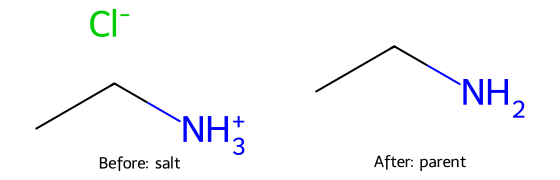

In [19]:
demo = pd.DataFrame({"smiles_raw": ["CC[NH3+].[Cl-]", "CCN"]})
demo[["smiles_std", "status"]] = pd.DataFrame(
    [standardize_smiles(s) for s in demo["smiles_raw"]])

display(demo)

assert demo["status"].eq("ok").all()
assert demo["smiles_std"].nunique() == 1
Draw.MolsToGridImage(
    [Chem.MolFromSmiles(demo.loc[0, "smiles_raw"]), Chem.MolFromSmiles(demo.loc[0, "smiles_std"])],
    legends=["Before: salt", "After: parent"], molsPerRow=2, subImgSize=(280, 180))


## B-3. 전체 데이터 표준화와 상태 확인
같은 함수를 모든 행에 적용합니다. 원본을 바꾸지 않고 smiles_std와 structure_status라는 새 열을 만듭니다. 첫 출력 전 잠시 기다려 주세요.

canonicalization만으로도 문자열 순서가 바뀔 수 있어, 원본 canonical SMILES와 표준화 결과를 비교합니다. 변경된 행 수는 측정값이 수정됐다는 뜻이 아닙니다. 처리 상태별 행 수와 걸린 시간이 출력됩니다.


In [21]:
# 1. SMILES 표준화
data[["smiles_std", "structure_status"]] = pd.DataFrame(
    [standardize_smiles(s) for s in data["smiles_raw"]],
    index=data.index
)

# 2. 원래 SMILES를 canonical SMILES로 변환
def canonical_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return Chem.MolToSmiles(mol)

data["smiles_canonical_raw"] = data["smiles_raw"].map(canonical_smiles)

# 3. 표준화 전후 구조 표현이 달라졌는지 확인
data["structure_changed"] = (
    data["smiles_std"] != data["smiles_canonical_raw"]
)

# 결과 확인
print(data["structure_status"].value_counts())
print("구조 표현이 바뀐 행 수:", data["structure_changed"].sum())

display(
    data.loc[
        data["structure_changed"],
        ["smiles_raw", "smiles_std"]
    ].head()
)

structure_status
ok    1128
Name: count, dtype: int64
구조 표현이 바뀐 행 수: 4


,smiles_raw,smiles_std
511,CSCS(=O)CC(CO)NC(=O)C=Cc1c(C)[nH]c(=O)[nH]c1=O,CSC[S+]([O-])CC(CO)NC(=O)C=Cc1c(C)[nH]c(=O)[nH...
518,CC(=O)N(S(=O)c1ccc(N)cc1)c2onc(C)c2C,CC(=O)N(c1onc(C)c1C)[S+]([O-])c1ccc(N)cc1
748,CCOP(=S)(OCC)Oc1ccc(cc1)S(C)=O,CCOP(=S)(OCC)Oc1ccc([S+](C)[O-])cc1
848,C=CCS(=O)SCC=C,C=CCS[S+]([O-])CC=C


## B-4. 정제와 중복 확인: 같은 구조가 두 시험지에 새지 않도록
다른 원본이 표준화 후 같은 구조가 될 수 있습니다. 그대로 random 분할하면 같은 화합물이 train과 test 양쪽에 들어가는 **데이터 누출**이 생길 수 있습니다.

간단하고 보수적인 수업 정책으로, **같은 표준화 구조가 여러 번 나오면 해당 행들을 모두 모델에서 제외**합니다. 첫 행을 임의로 고르거나 logS를 평균내지 않습니다. 실제 연구에서는 조건·값 차이를 검토한 뒤 반복 측정 통합이나 그룹 분할을 선택합니다.

원본은 data에 모두 남겨 두고 model_status에 사유를 기록합니다. 아래 집계의 합이 원본 행 수와 일치해야 합니다. df는 실제 모델용 데이터입니다.


In [23]:
# 1. 기본 상태 복사
data["model_status"] = data["structure_status"]


# 2. logS 값이 없는 행 제외
missing_logS = (
    (data["structure_status"] == "ok") &
    (~np.isfinite(data["logS"]))
)

data.loc[missing_logS, "model_status"] = "missing_logS"


# 3. 구조가 중복된 화합물 찾기
usable_rows = data["model_status"] == "ok"

duplicate_rows = (
    usable_rows &
    data["smiles_std"].duplicated(keep=False)
)

data.loc[duplicate_rows, "model_status"] = "duplicate_structure_review"


# 4. 최종적으로 모델에 사용할 데이터만 선택
df = data[data["model_status"] == "ok"].copy()

# index를 0부터 다시 정리
df = df.reset_index(drop=True)


# 5. SMILES를 RDKit molecule 객체로 변환
df["mol"] = df["smiles_std"].map(Chem.MolFromSmiles)


# 6. 결과 확인
print("모델 사용/제외 사유:")
print(data["model_status"].value_counts())

print("\n모델용 화합물 수:", len(df))


# 제외된 데이터 일부 확인
display(
    data[data["model_status"] != "ok"].head()
)

모델 사용/제외 사유:
model_status
ok                            1106
duplicate_structure_review      22
Name: count, dtype: int64

모델용 화합물 수: 1106


,source_row,compound_id,smiles_raw,logS,smiles_std,structure_status,smiles_canonical_raw,structure_changed,model_status
147,147,Amobarbital,CCC1(CCC(C)C)C(=O)NC(=O)NC1=O,-2.468,CCC1(CCC(C)C)C(=O)NC(=O)NC1=O,ok,CCC1(CCC(C)C)C(=O)NC(=O)NC1=O,False,duplicate_structure_review
213,213,eucalyptol,CC12CCC(CC1)C(C)(C)O2,-1.640,CC12CCC(CC1)C(C)(C)O2,ok,CC12CCC(CC1)C(C)(C)O2,False,duplicate_structure_review
222,222,2-bromonaphthalene,c1c(Br)ccc2ccccc12,-4.400,Brc1ccc2ccccc2c1,ok,Brc1ccc2ccccc2c1,False,duplicate_structure_review
232,232,Epiandrosterone,CC34CCC1C(CCC2CC(O)CCC12C)C3CCC4=O,-4.160,CC12CCC3C(CCC4CC(O)CCC43C)C1CCC2=O,ok,CC12CCC3C(CCC4CC(O)CCC43C)C1CCC2=O,False,duplicate_structure_review
233,233,mannitol,OCC(O)C(O)C(O)C(O)CO,0.060,OCC(O)C(O)C(O)C(O)CO,ok,OCC(O)C(O)C(O)C(O)CO,False,duplicate_structure_review
